# uvfit Tutorial: KinMS Mock Data

This notebook uses the **first example from the [KinMS introduction](https://github.com/TimothyADavis/KinMSpy)** as the mock dataset: we generate a 3D kinematic cube with KinMS (exponential surface brightness, arctan velocity curve, inclined disk), simulate interferometric visibilities from it, then fit with **uvfit** using a noisy version of the cube as template. At the end we show the best-fit model cube.

## 1. Imports

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import RegularGridInterpolator

from kinms import KinMS
from uvfit import UVDataset, TemplateCubeModel, Fitter

# Optional: for MCMC corner plot and correlation matrix
try:
    import corner
    HAS_CORNER = True
except ImportError:
    HAS_CORNER = False
    print("Install 'corner' for corner plot: pip install corner")

## 2. KinMS first example: generate the mock cube

We follow the [KinMS example notebook](https://github.com/TimothyADavis/KinMSpy): exponential surface brightness, arctan velocity profile, inclined disk. This cube will be our "true" sky; we later simulate visibilities from it and fit with uvfit using the same cube as template.

In [2]:
# Radial profiles (from KinMS example)
scalerad = 10  # arcseconds
radius = np.arange(0, 1000, 0.1)
sbprof = np.exp(-radius / scalerad)

vel = 210 * (2 / np.pi) * np.arctan(radius)  # km/s

pos = 270   # position angle, degrees
inc = 45    # inclination, degrees

In [3]:
# Cube and observation parameters (KinMS first example)
xsize = 128    # arcsec
ysize = 128    # arcsec
vsize = 700    # km/s
cellsize = 1   # arcsec/pixel
dv = 10        # km/s per channel
beamsize = [4, 4, 0]  # arcsec, arcsec, degrees

kin = KinMS(xsize, ysize, vsize, cellsize, dv, beamSize=beamsize, verbose=False)
cube_kinms = kin.model_cube(inc=inc, sbProf=sbprof, sbRad=radius, velProf=vel, posAng=pos)

# KinMS returns cube shape (x_size, y_size, v_size); uvfit expects (n_chan, ny, nx)
cube = np.transpose(cube_kinms, (2, 1, 0)).astype(np.float64)
n_chan, ny, nx = cube.shape

# Shared relative noise level for both template cube and visibility data (same realism in both)
rel_noise = 0.1
rng_template = np.random.default_rng(44)
sigma_pixel = rel_noise * np.max(cube)
template_cube = np.maximum(
    cube + sigma_pixel * rng_template.standard_normal(cube.shape), 0.0
).astype(np.float64)

print(f"Cube shape (n_chan, ny, nx): {cube.shape}")
print(f"Template: noisy cube (rel_noise={rel_noise}, sigma_pixel = {sigma_pixel:.4f})")
print(f"Cell size: {cellsize} arcsec")

Cube shape (n_chan, ny, nx): (70, 128, 128)
Template: noisy cube (rel_noise=0.1, sigma_pixel = 0.0001)
Cell size: 1 arcsec


## 3. Simulate visibilities and build UVDataset

We sample the clean cube in the uv-plane (FFT per channel + interpolate at random baselines) with no noise on the visibilities, and build a uvfit `UVDataset`. (Noise is only in the template cube above, so we do not add it here.) No new uvfit functionality is required—we use the same approach as in `scripts/generate_mock_data.py`.

In [ ]:
def simulate_visibilities(cube, cell_size, n_baselines=200, noise_sigma=0.02, seed=42):
    """Sample cube at random (u,v), add noise. Returns u, v (wavelengths), vis, weights, freqs."""
    rng = np.random.default_rng(seed)
    n_chan, ny, nx = cube.shape
    cell_rad = cell_size * np.pi / (180.0 * 3600.0)
    u_grid = np.fft.fftshift(np.fft.fftfreq(nx, d=cell_rad))
    v_grid = np.fft.fftshift(np.fft.fftfreq(ny, d=cell_rad))
    u_max, v_max = u_grid.max() * 0.8, v_grid.max() * 0.8
    u = rng.uniform(-u_max, u_max, size=n_baselines)
    v = rng.uniform(-v_max, v_max, size=n_baselines)
    vis = np.zeros((n_baselines, n_chan), dtype=np.complex128)
    for ch in range(n_chan):
        ft = np.fft.fftshift(np.fft.fft2(np.fft.ifftshift(cube[ch])))
        interp_re = RegularGridInterpolator(
            (v_grid, u_grid), ft.real, method="linear", bounds_error=False, fill_value=0.0
        )
        interp_im = RegularGridInterpolator(
            (v_grid, u_grid), ft.imag, method="linear", bounds_error=False, fill_value=0.0
        )
        points = np.stack([v, u], axis=-1)
        vis[:, ch] = interp_re(points) + 1j * interp_im(points)
    noise = noise_sigma * (rng.standard_normal(vis.shape) + 1j * rng.standard_normal(vis.shape))
    vis_noisy = vis + noise
    weights = np.ones_like(vis_noisy.real) if noise_sigma == 0 else np.full_like(vis_noisy.real, 1.0 / noise_sigma**2)
    freq_center = 230.538e9
    chan_width = 1e6
    freqs = freq_center + (np.arange(n_chan) - n_chan / 2) * chan_width
    return u, v, vis_noisy, weights, freqs

n_baselines = 200
# Visibilities from the *true* cube; then add noise at the same relative level as the template
u, v, vis_clean, _, freqs = simulate_visibilities(
    cube, cellsize, n_baselines=n_baselines, noise_sigma=0.0
)
vis_rms = np.sqrt(np.mean(vis_clean.real**2 + vis_clean.imag**2))
noise_sigma_vis = rel_noise * vis_rms
rng_vis = np.random.default_rng(45)
noise = noise_sigma_vis * (rng_vis.standard_normal(vis_clean.shape) + 1j * rng_vis.standard_normal(vis_clean.shape))
vis_noisy = vis_clean + noise
weights = np.full_like(vis_noisy.real, 1.0 / noise_sigma_vis**2)
uvdata = UVDataset.from_mock(u=u, v=v, vis=vis_noisy, weights=weights, freqs=freqs)
print(f"UV data: {uvdata.n_baseline} baselines × {uvdata.n_chan} channels (true cube + noise, rel_noise={rel_noise})")

UV data: 200 baselines × 70 channels


## 4. Fit: gradient (L-BFGS-B) then MCMC

To simulate reality, the model is derived from a **noisy** cube and the visibility data are from the true cube with **the same relative noise** added: `rel_noise` sets both template pixel noise and visibility noise. The model parameters are (dx, dy, dv, flux_scale); the true values (no shift, no scaling) are (0, 0, 0, 1). We start from deliberately wrong initial guesses, first run a **gradient-based fit (L-BFGS-B)** to find a good starting point, then run **MCMC (emcee)** to recover the posterior and uncertainties.

In [ ]:
model = TemplateCubeModel(template_cube=template_cube, cell_size_arcsec=cellsize)
fitter = Fitter(uvdata=uvdata, forward_model=model)

initial_params = {"dx": 2.0, "dy": -1.5, "dv": 2.0, "flux_scale": 0.7}

# 4a. Gradient fit (L-BFGS-B)
print("Running gradient fit (L-BFGS-B)...")
result_grad = fitter.fit(initial_params=initial_params, method="L-BFGS-B")
print("Gradient fit result:", result_grad.params)
print("Reduced χ²:", result_grad.reduced_chi2)

Running gradient fit (L-BFGS-B)...
Gradient fit result: {'dx': 2.0, 'dy': -1.5, 'dv': 2.0, 'flux_scale': 0.7}
Reduced χ²: 1.0129772411164564


### 4b. MCMC (emcee)

Run MCMC from the gradient best-fit to sample the posterior.

In [ ]:
print("Running MCMC (emcee) from gradient best-fit...")
result = fitter.fit(
    initial_params=result_grad.params,
    method="emcee",
    n_walkers=32,
    n_steps=400,
    n_burn=100,
)
print("MCMC done. Best-fit (MAP) params:", result.params)
print("True (KinMS) would be: dx=0, dy=0, dv=0, flux_scale=1")

Running MCMC (emcee) from gradient best-fit...


  1%|          | 4/400 [00:34<57:30,  8.71s/it]

## 6. Show the model

Best-fit model cube (noisy template shifted and scaled at the fitted parameters): moment-0 map and central spectrum.

In [4]:
model_cube = model.generate_cube(result.params)
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
mom0_model = np.sum(model_cube, axis=0)
axes[0].imshow(mom0_model, origin="lower", aspect="equal")
axes[0].set_title("Moment 0 (best-fit model)")
axes[0].set_xlabel("x (pix)")
axes[0].set_ylabel("y (pix)")
cy, cx = ny // 2, nx // 2
spec_model = model_cube[:, cy, cx]
axes[1].plot(np.arange(n_chan), spec_model, "r-", label="Model")
axes[1].set_xlabel("Channel")
axes[1].set_ylabel("Flux")
axes[1].set_title("Spectrum at centre (model)")
axes[1].legend()
plt.tight_layout()
plt.show()

NameError: name 'model' is not defined

## 5b. Posterior distribution and corner plot

We use the MCMC chains (after burn-in) to plot the **posterior distribution** (corner plot) and the **correlation matrix** between parameters. True values for the template are (dx, dy, dv, flux_scale) = (0, 0, 0, 1).

In [ ]:
param_names = list(result.params.keys())
# Flatten chains: (n_steps, n_walkers, n_params) -> (n_samples, n_params)
samples = result.chains.reshape(-1, result.chains.shape[-1])

# Correlation matrix from posterior samples
corr = np.corrcoef(samples.T)
fig_corr, ax_corr = plt.subplots(figsize=(5, 4))
im = ax_corr.imshow(corr, vmin=-1, vmax=1, cmap="RdBu_r")
ax_corr.set_xticks(range(len(param_names)))
ax_corr.set_yticks(range(len(param_names)))
ax_corr.set_xticklabels(param_names)
ax_corr.set_yticklabels(param_names)
for i in range(len(param_names)):
    for j in range(len(param_names)):
        ax_corr.text(j, i, f"{corr[i, j]:.2f}", ha="center", va="center", fontsize=10)
plt.colorbar(im, ax=ax_corr, label="Correlation")
ax_corr.set_title("Posterior correlation matrix")
plt.tight_layout()
plt.show()

In [ ]:
# Walker evolution: each parameter vs step, with true values
true_values = [0.0, 0.0, 0.0, 1.0]  # dx, dy, dv, flux_scale
chains = result.chains  # (n_steps, n_walkers, n_params)
n_steps = chains.shape[0]

fig_walk, axes_walk = plt.subplots(2, 2, figsize=(10, 8), sharex=True)
axes_walk = axes_walk.ravel()
for i, (name, true_val) in enumerate(zip(param_names, true_values)):
    for w in range(chains.shape[1]):
        axes_walk[i].plot(np.arange(n_steps), chains[:, w, i], color="C0", alpha=0.25)
    axes_walk[i].axhline(true_val, color="C1", ls="--", lw=2, label="true")
    axes_walk[i].set_ylabel(name)
    axes_walk[i].legend(loc="upper right")
    axes_walk[i].grid(True, alpha=0.3)
axes_walk[2].set_xlabel("Step (post burn-in)")
axes_walk[3].set_xlabel("Step (post burn-in)")
fig_walk.suptitle("MCMC walkers around true values", y=1.02)
plt.tight_layout()
plt.show()

In [ ]:
# Corner plot (posterior distributions)
if HAS_CORNER:
    fig_corner = corner.corner(samples, labels=param_names, truths=[0, 0, 0, 1],
                               truth_color="C1", show_titles=True, title_fmt=".3f")
    fig_corner.suptitle("Posterior distribution (MCMC)", y=1.02)
    plt.show()
else:
    # Fallback: 1D marginals
    fig, axes = plt.subplots(2, 2, figsize=(8, 6))
    axes = axes.ravel()
    for i, name in enumerate(param_names):
        axes[i].hist(samples[:, i], bins=50, density=True, alpha=0.7, color="steelblue", edgecolor="none")
        axes[i].axvline([0, 0, 0, 1][i], color="C1", ls="--", label="truth")
        axes[i].set_xlabel(name)
        axes[i].set_ylabel("Density")
        axes[i].legend()
    plt.suptitle("Posterior marginals (no corner package)")
    plt.tight_layout()
    plt.show()

## 5. Quick visualization (noisy template cube)

Moment-0 map of the noisy template cube (used for the model) and spectrum at the centre.

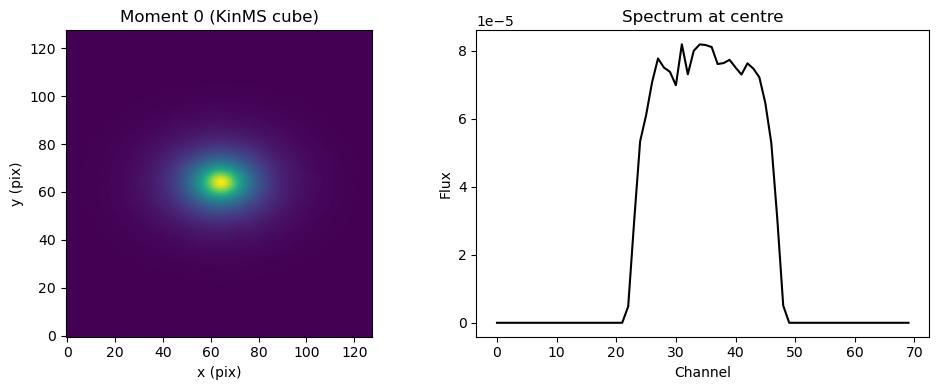

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
mom0 = np.sum(template_cube, axis=0)
axes[0].imshow(mom0, origin="lower", aspect="equal")
axes[0].set_title("Moment 0 (noisy template cube)")
axes[0].set_xlabel("x (pix)")
axes[0].set_ylabel("y (pix)")

cy, cx = ny // 2, nx // 2
spec = template_cube[:, cy, cx]
axes[1].plot(np.arange(n_chan), spec, "k-")
axes[1].set_xlabel("Channel")
axes[1].set_ylabel("Flux")
axes[1].set_title("Spectrum at centre (noisy template)")
plt.tight_layout()
plt.show()